In [1]:
%load_ext autoreload
%autoreload 2
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from mne.time_frequency import tfr_morlet
from mne.time_frequency.tfr import morlet
from mne import combine_evoked
import seaborn as sns
from mne.decoding import Scaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import PowerTransformer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
paradigm = P300(tmin=-2, tmax=2, resample=None, fmin=0.1, fmax=None)
dataset = BNCI2014008()

In [3]:
subject, session, run = 1, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.


<RawArray | 10 x 347704 (1358.2 s), ~26.5 MB, data loaded>

Effective window size : 1.000 (s)


/home/arne/.virtualenvs/hoda-venv/lib/python3.10/site-packages/mne/viz/utils.py:137: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  (fig or plt).show(**kwargs)


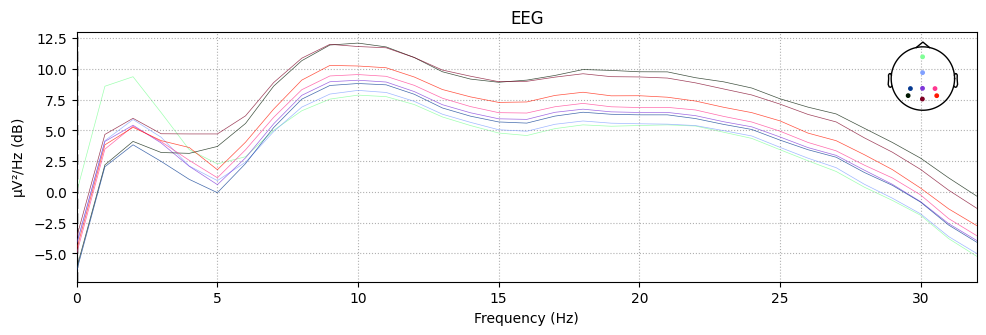

In [4]:
import matplotlib.pyplot as plt
raw.compute_psd(fmax=32).plot(show=True)
plt.show()

In [5]:
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,-2.000 – 2.000 sec
Baseline,off


    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs...


/home/arne/.virtualenvs/hoda-venv/lib/python3.10/site-packages/mne/viz/utils.py:137: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  (fig or plt).show(**kwargs)


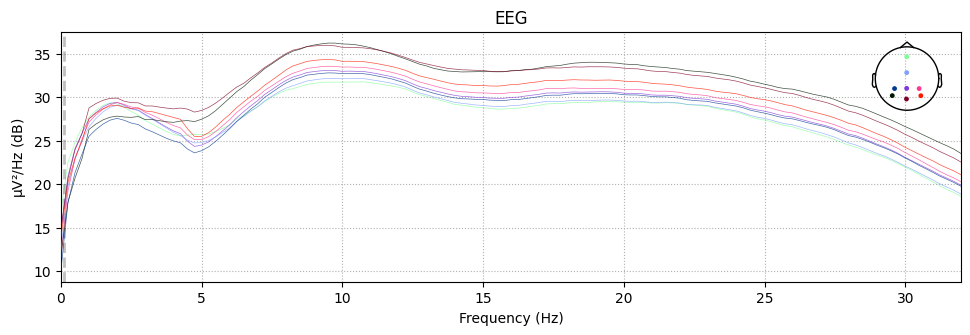

In [6]:
_ = epochs.compute_psd(fmax=32).plot(show=True)
plt.show()

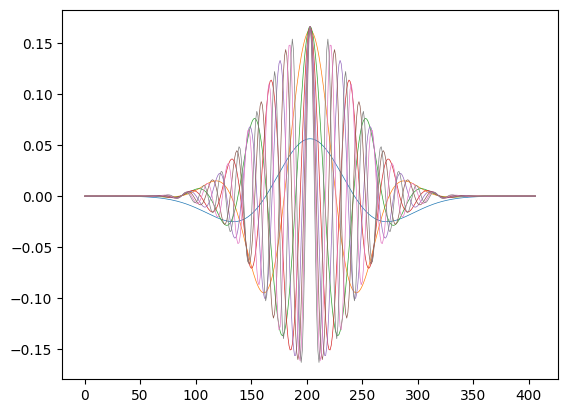

In [7]:
sfreq=32
n_freqs=8
freqs = np.linspace(0.5, 16, n_freqs)
n_cycles = freqs
wavelets = morlet(epochs.info['sfreq'],
                  freqs, n_cycles, zero_mean=True)
for i in range(n_freqs):
    plt.plot(np.real(wavelets[i]), linewidth=0.5)
plt.show()

In [74]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.special

def mean_angle(arr):
    return np.arctan2(np.mean(np.sin(arr)),np.mean(np.cos(arr)))

def angle_dist(a1, a2):
    return np.abs(a2-a1) % np.pi

# TFR transform
epochs_tfr = tfr_morlet(epochs, freqs, n_cycles, return_itc=False, average=False,
                    output='complex', verbose=True, n_jobs=-1, decim=int(epochs.info['sfreq']//sfreq))
epochs_tfr.data =np.angle(epochs_tfr)
sm.qqplot(epochs_tfr.data.flatten(), line ='45')
plt.show()

# Baseline correction
"""
epochs_tfr_baseline = epochs_tfr.copy().crop(-0.5, 0)
for f in range(n_freqs):
    for c in range(len(epochs_tfr.ch_names)):
        for i in range(len(epochs_tfr)):
            mean_phase = mean_angle(epochs_tfr_baseline.data[i,c,f,:])
            epochs_tfr.data[i,c,f,:] = np.abs(epochs_tfr.data[i,c,f,:] - mean_phase)%np.pi
""""
epochs_tfr.data = scipy.special.logit(epochs_tfr.data/np.pi)     

epochs_tfr.crop(0.0, 0.8)
sm.qqplot(epochs_tfr.data.flatten(), line ='45')
plt.show()

SyntaxError: unterminated string literal (detected at line 26) (3867461698.py, line 26)

No baseline correction applied


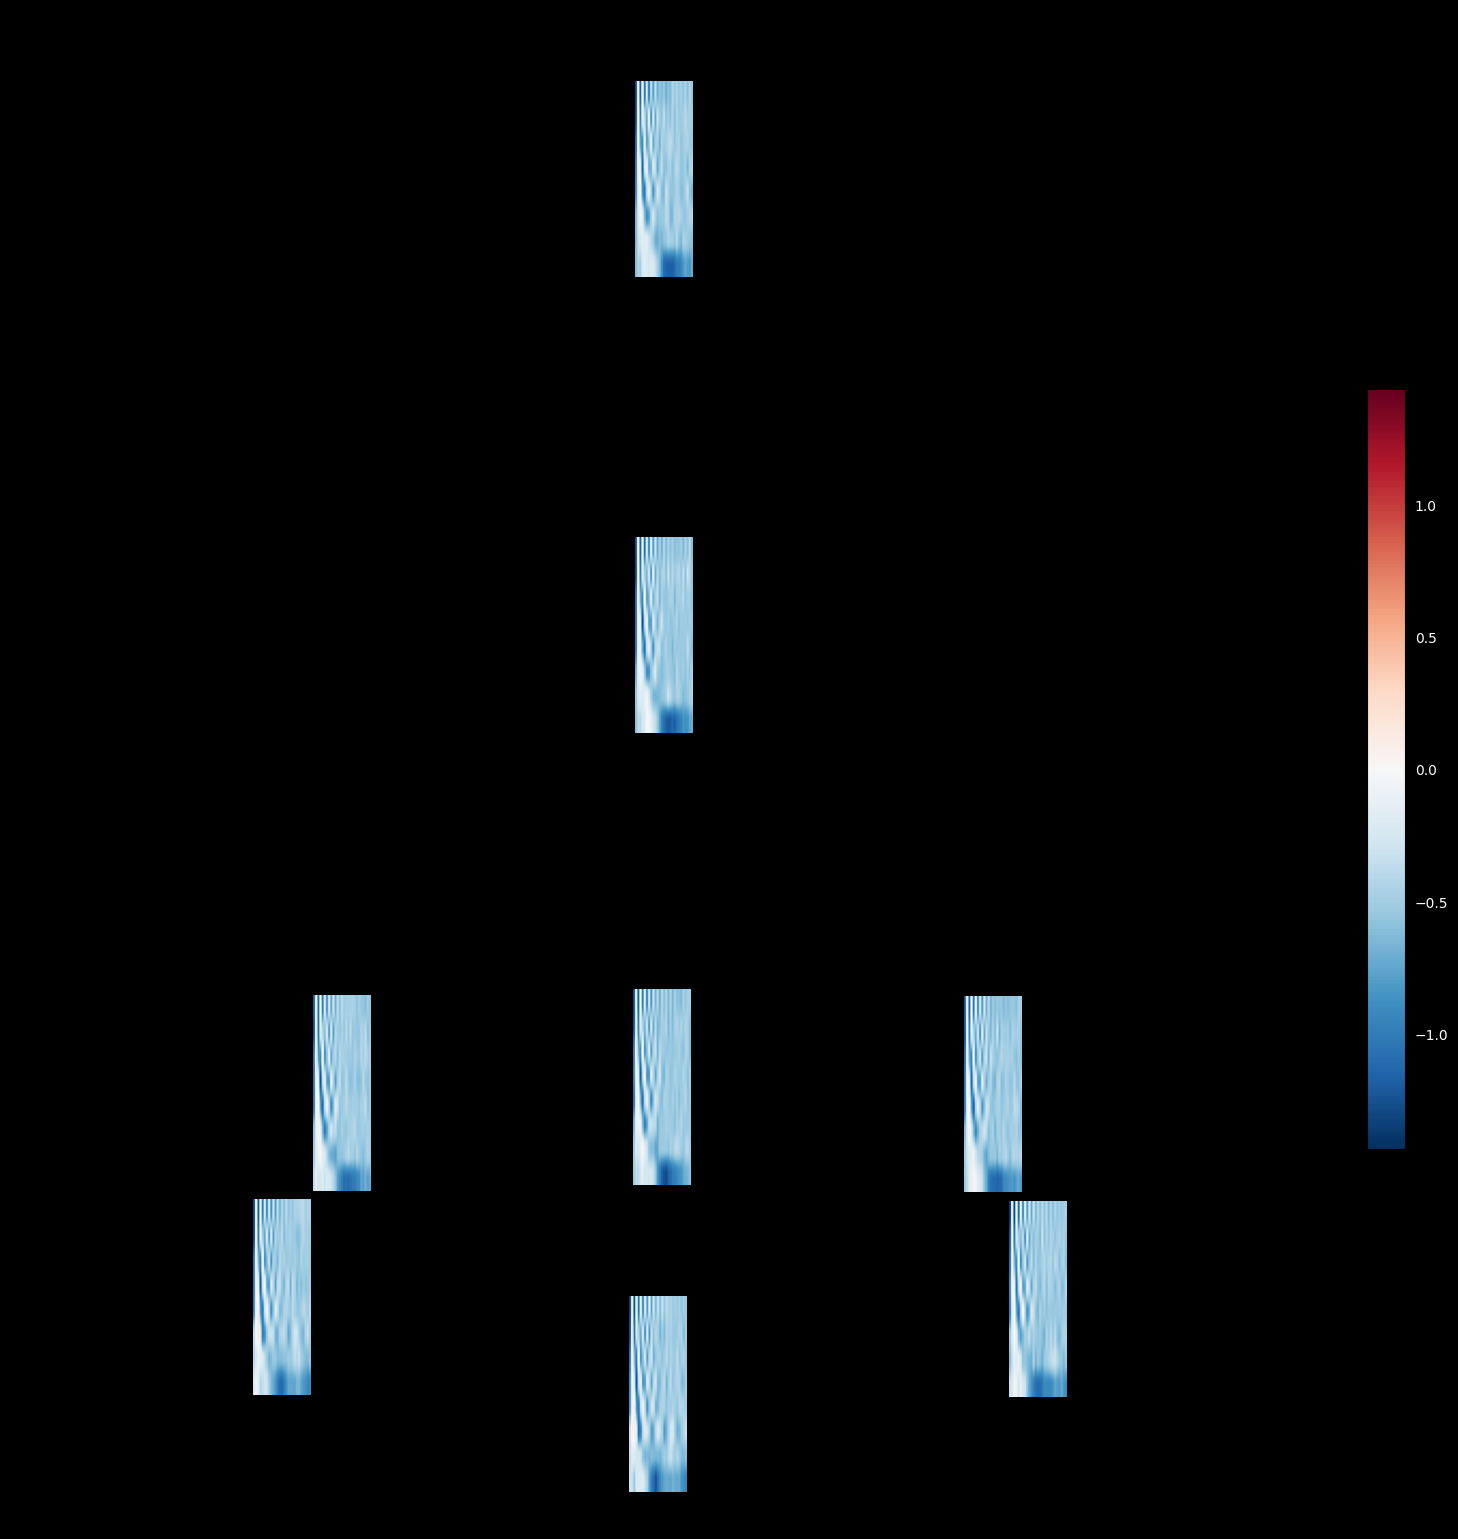

In [52]:
class_names = np.unique(labels)
avg_target = epochs_tfr['Target'].average()
fig = avg_target.plot_topo(show=False)
fig.set_size_inches(16, 16)
plt.show()

No baseline correction applied


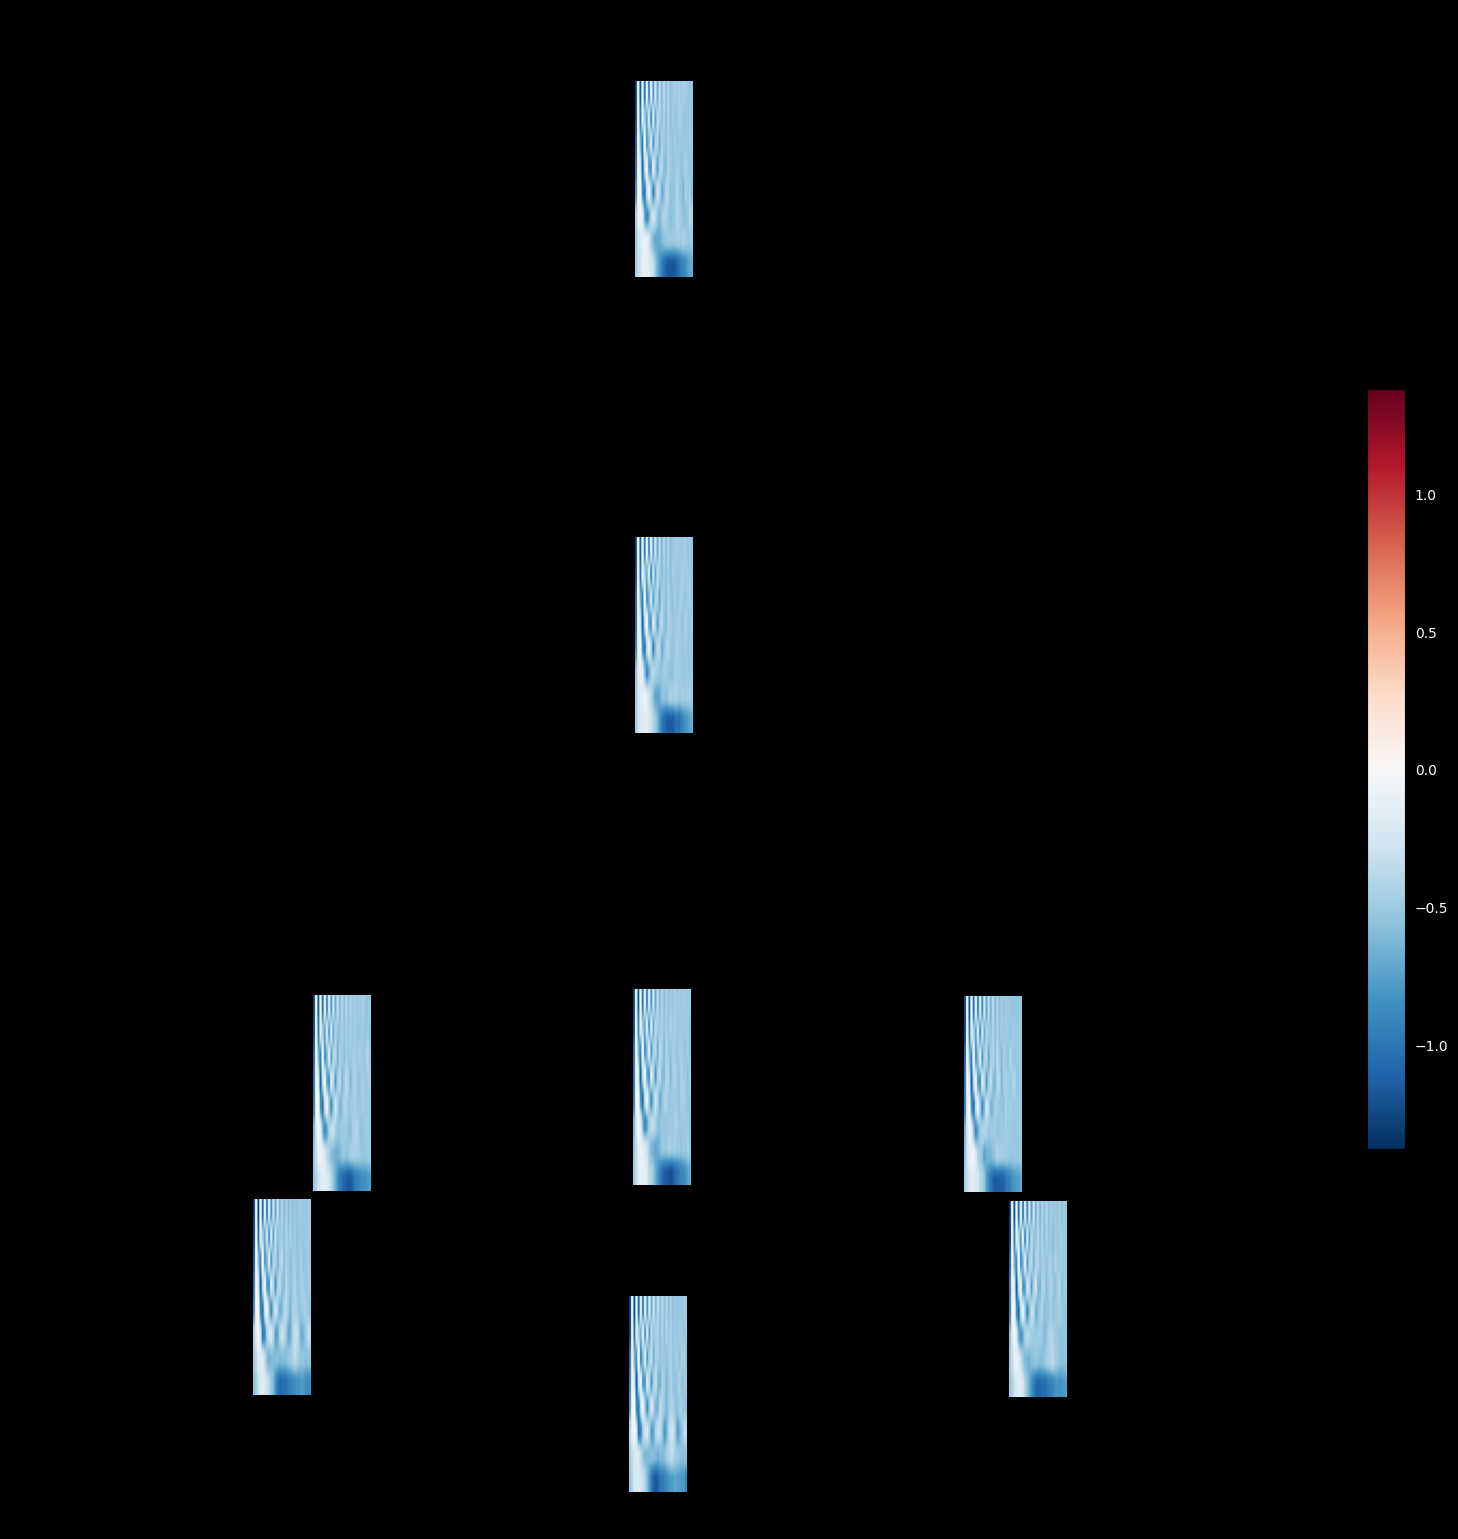

In [53]:
avg_non_target = epochs_tfr['NonTarget'].average()
fig = avg_non_target.plot_topo(show=False)
fig.set_size_inches(16, 16)
plt.show()

No baseline correction applied


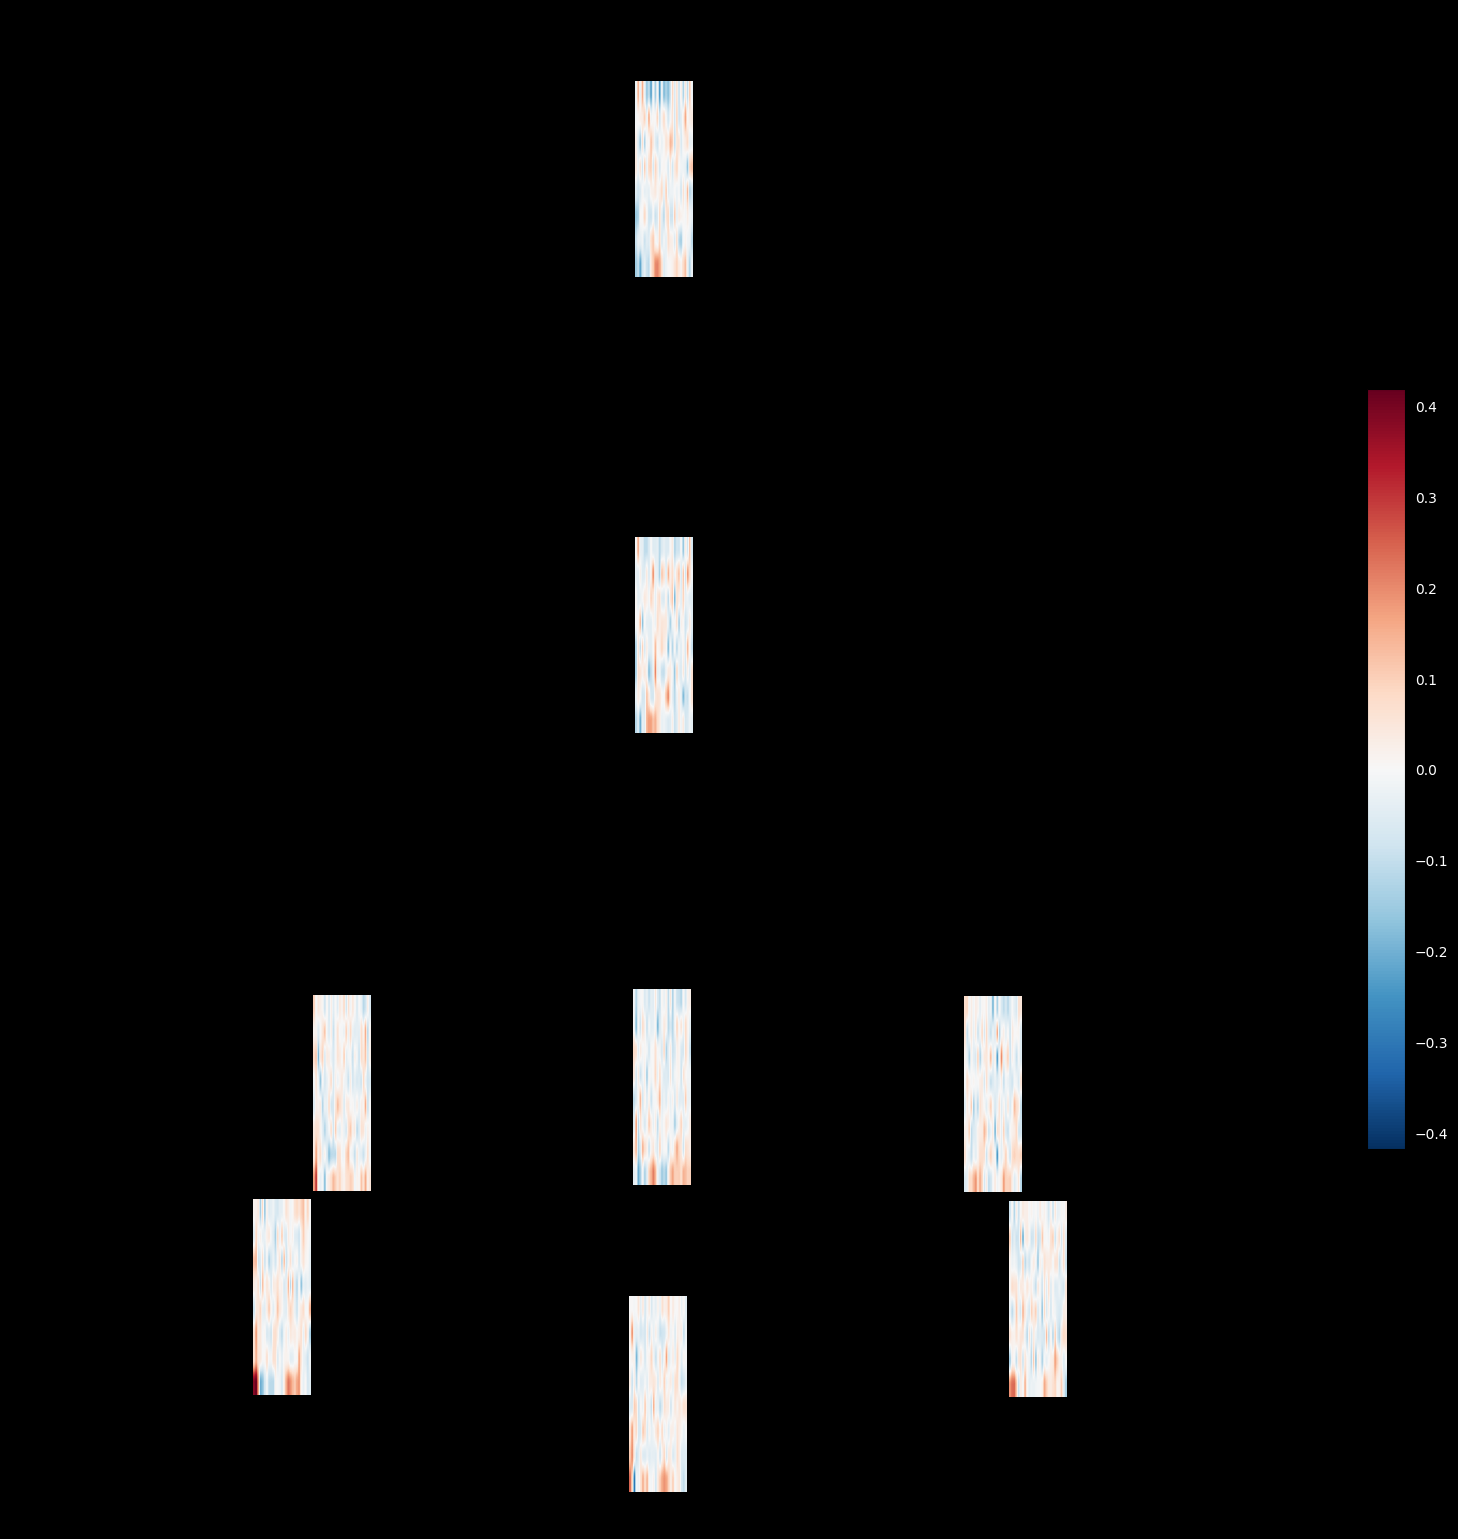

In [54]:
from mne import combine_evoked
from mne.viz import plot_tfr_topomap

contrast = combine_evoked([avg_target, avg_non_target], weights = [1,-1])
fig = contrast.plot_topo(show=False)
fig.set_size_inches(16, 16)
plt.show()

In [55]:
#epochs_data_flat = epochs.data.flatten()
#sns.jointplot(x=np.real(epochs_data_flat), y=np.imag(epochs_data_flat),kind="hex")

In [56]:
split = len(epochs)//2
epochs_train = epochs_tfr[:split]
epochs_test = epochs_tfr[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [57]:
X_train = epochs_train.data.astype(np.float32)
y_train = labels_train
X_test = epochs_test.data.astype(np.float32)
y_test = labels_test

In [58]:
X_train -= np.mean(X_train, axis=0)[np.newaxis,:,:,:]
X_train /= np.std(X_train, axis=0)[np.newaxis,:,:,:]
X_test -= np.mean(X_train, axis=0)[np.newaxis,:,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:,:]

In [59]:
import tensorly as tl
try:
    tl.set_backend('jax')
except AttributeError:
    tl.set_backend('jax')

In [60]:
hoda = HODA(max_iter=32, rank=(2,2,2), tol=0, initialize ='identity', verbose=True, 
            shrinkage=(0.5,0.5,0.5))
hoda.fit(X_train,y_train)

[0/32]  shrinkage[0]=0.5000  shrinkage[1]=0.5000  shrinkage[2]=0.5000  step=2.3158e+00
[1/32]  shrinkage[0]=0.5000  shrinkage[1]=0.5000  shrinkage[2]=0.5000  step=1.7963e+00
[2/32]  shrinkage[0]=0.5000  shrinkage[1]=0.5000  shrinkage[2]=0.5000  step=1.6004e+00
[3/32]  shrinkage[0]=0.5000  shrinkage[1]=0.5000  shrinkage[2]=0.5000  step=1.6556e+00
[4/32]  shrinkage[0]=0.5000  shrinkage[1]=0.5000  shrinkage[2]=0.5000  step=1.3067e+00
[5/32]  shrinkage[0]=0.5000  shrinkage[1]=0.5000  shrinkage[2]=0.5000  step=1.2249e+00
[6/32]  shrinkage[0]=0.5000  shrinkage[1]=0.5000  shrinkage[2]=0.5000  step=7.9774e-01
[7/32]  shrinkage[0]=0.5000  shrinkage[1]=0.5000  shrinkage[2]=0.5000  step=7.0880e-01
[8/32]  shrinkage[0]=0.5000  shrinkage[1]=0.5000  shrinkage[2]=0.5000  step=6.9316e-01
[9/32]  shrinkage[0]=0.5000  shrinkage[1]=0.5000  shrinkage[2]=0.5000  step=6.0206e-01
[10/32]  shrinkage[0]=0.5000  shrinkage[1]=0.5000  shrinkage[2]=0.5000  step=6.0652e-01
[11/32]  shrinkage[0]=0.5000  shrinkage[1]

HODA(max_iter=32, rank=(2, 2, 2), shrinkage=(0.5, 0.5, 0.5), tol=0,
     verbose=True)

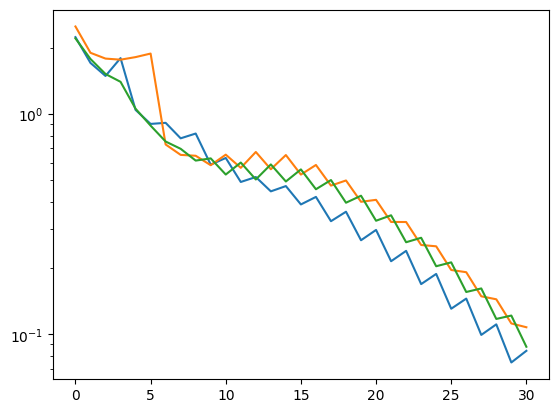

In [61]:
plt.semilogy(hoda.updates_[:,:hoda.iter_].T)
plt.show()

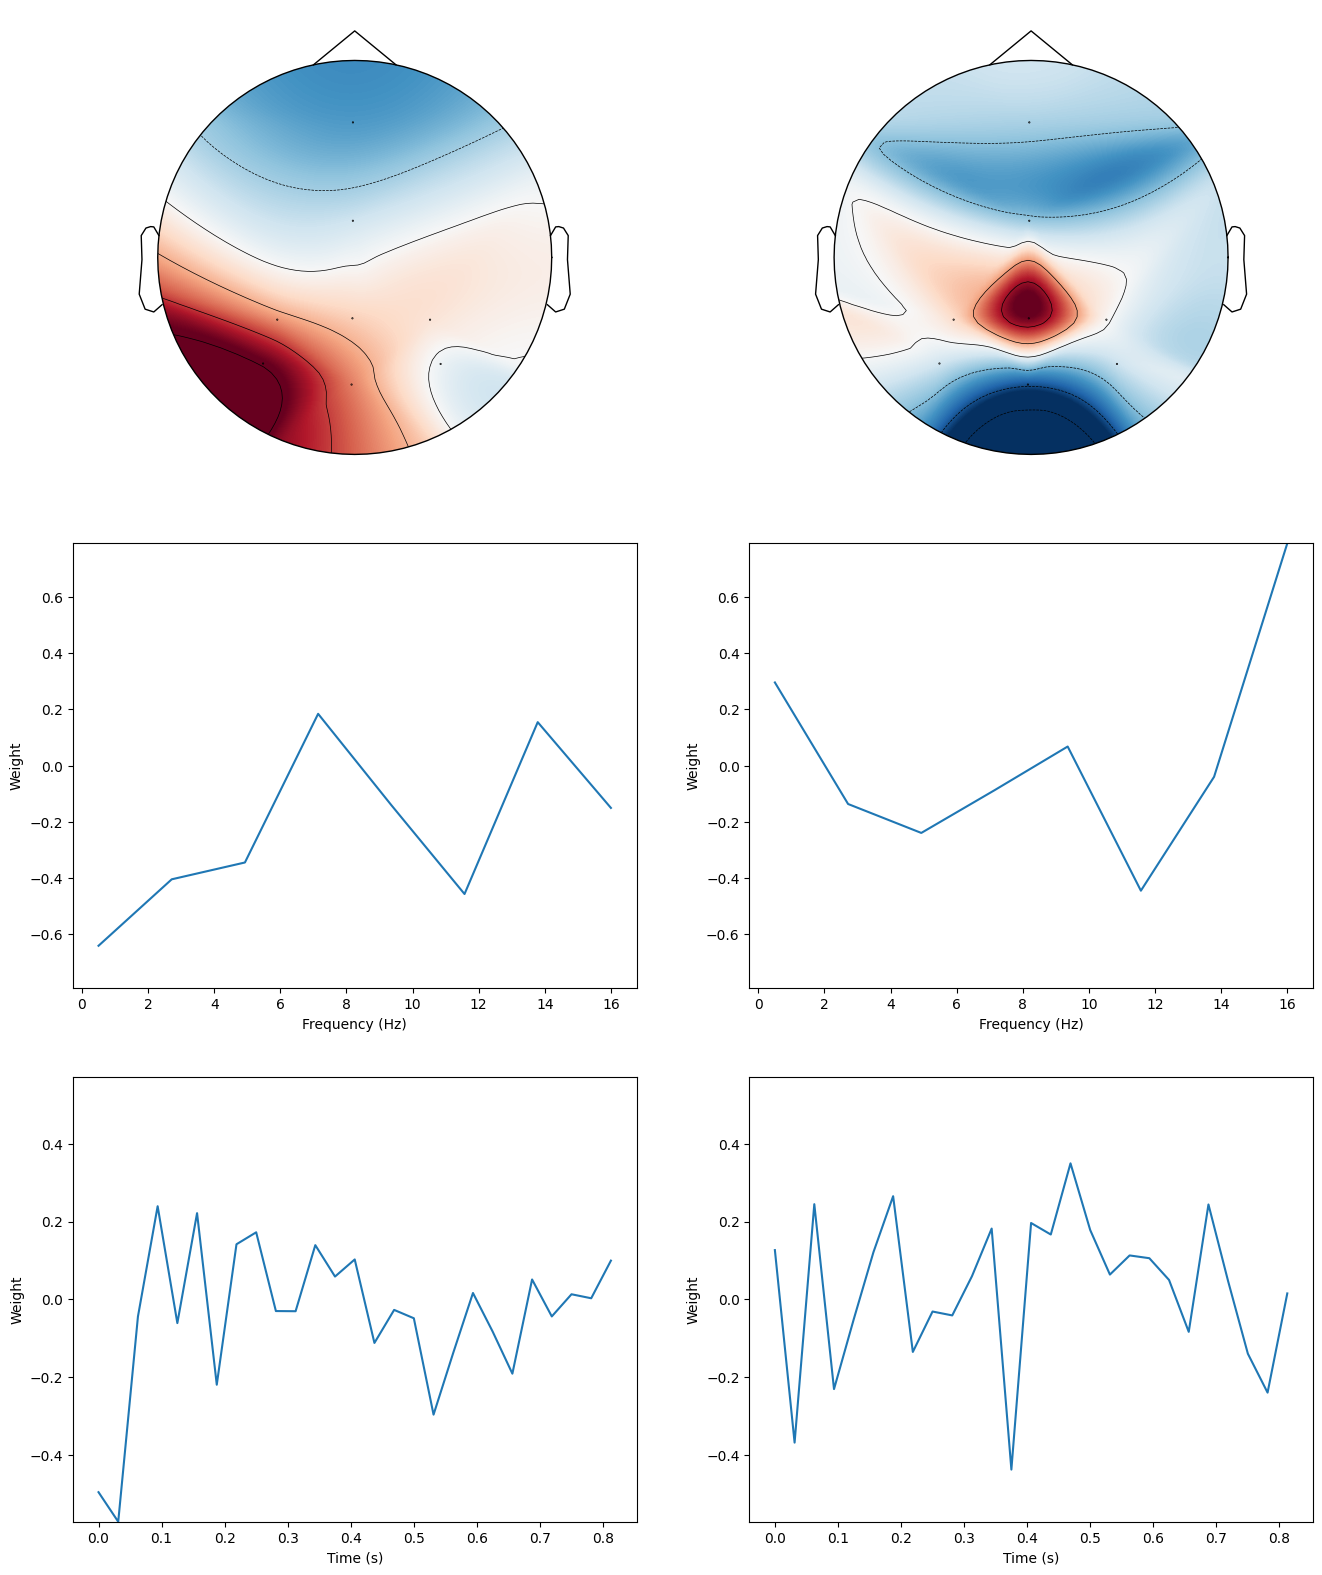

In [64]:
fig, axs = plt.subplots(3,max(hoda.rank), figsize=(16,6*3))
sp_rank = min(hoda.rank[0], len(epochs.ch_names))
for i in range(sp_rank):
    w = hoda.projs_[0][:,i]
    if sp_rank >1:
        plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(hoda.projs_[1]))
for i in range(hoda.rank[1]):
    w = hoda.projs_[1][:,i]
    axs[1,i].plot(freqs, w)
    axs[1,i].set_xlabel('Frequency (Hz)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])
vmax = np.max(np.abs(hoda.projs_[2]))
for i in range(hoda.rank[2]):
    w = hoda.projs_[2][:,i]
    axs[2,i].plot(epochs_tfr.times, w)
    axs[2,i].set_xlabel('Time (s)')
    axs[2,i].set_ylabel('Weight')
    axs[2,i].set_ylim([-vmax, vmax])
plt.show()

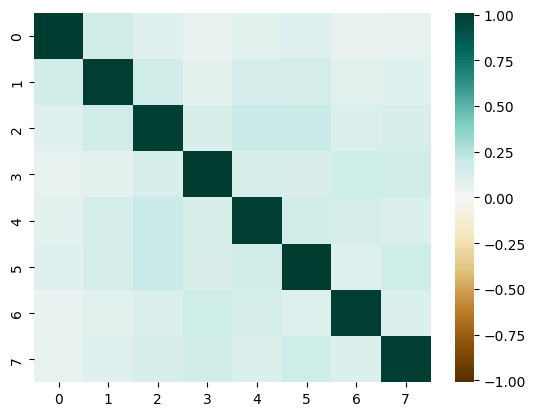

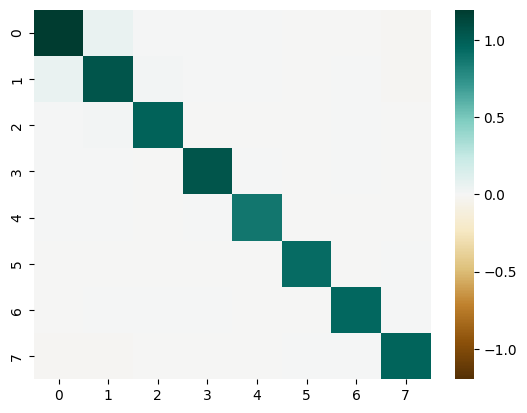

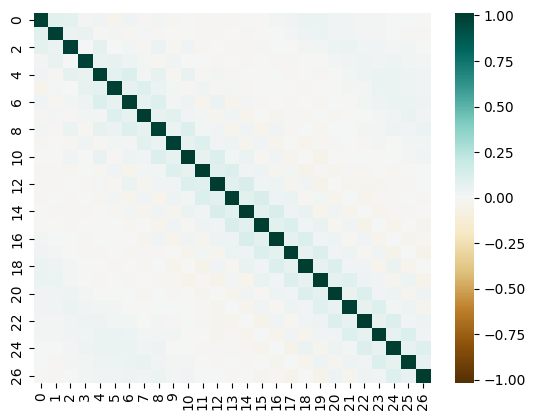

In [65]:
for k in range(3):
    cov = hoda.scatter_w_[k]
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

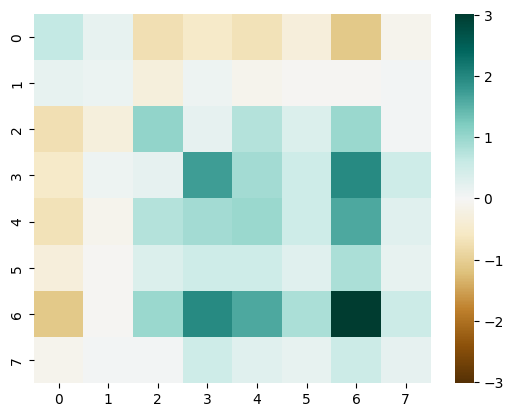

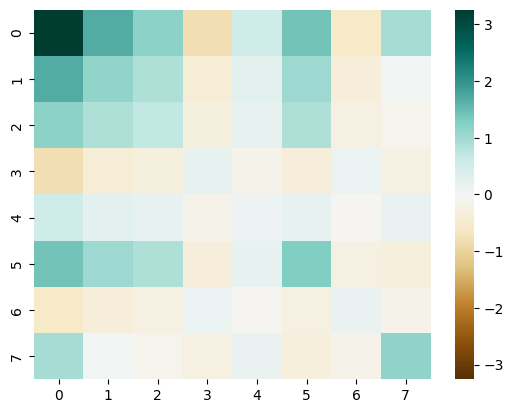

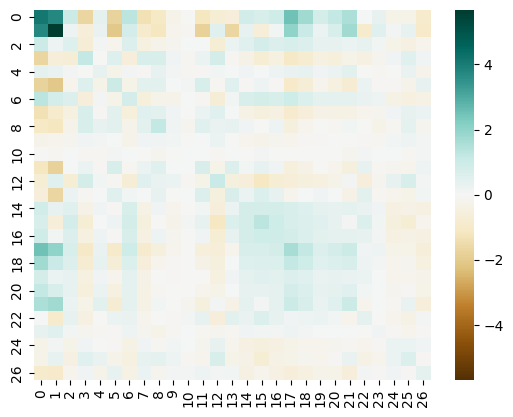

In [66]:
for k in range(3):
    cov = hoda.scatter_b_[k]
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

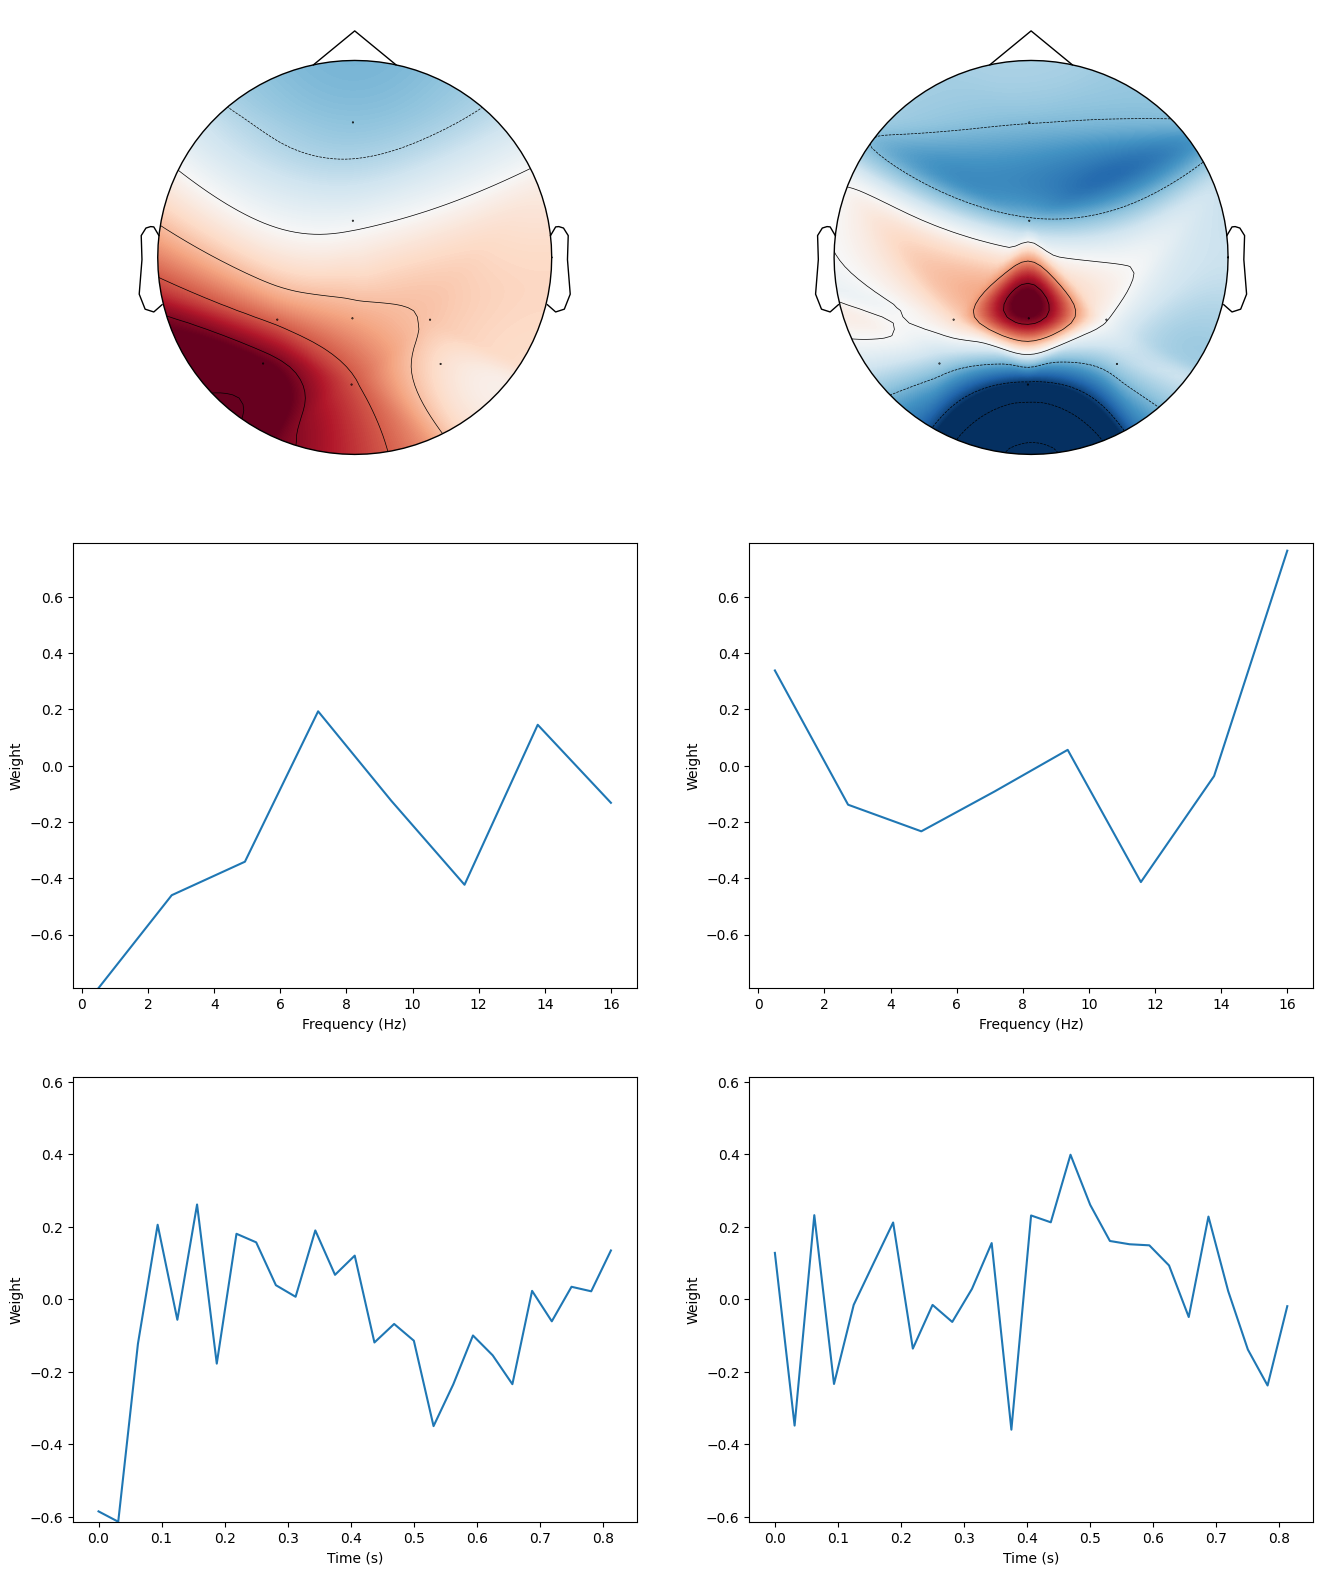

In [67]:
fig, axs = plt.subplots(3,max(hoda.rank), figsize=(16,6*3))
aps = [hoda.scatter_w_[k] @ p for k,p in enumerate(hoda.projs_)]
for i in range(sp_rank):
    w = aps[0][:,i]
    if sp_rank > 1:
        plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(aps[1]))
for i in range(hoda.rank[1]):
    w = aps[1][:,i]
    axs[1,i].plot(freqs, w)
    axs[1,i].set_xlabel('Frequency (Hz)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])
vmax = np.max(np.abs(aps[2]))
for i in range(hoda.rank[2]):
    w = aps[2][:,i]
    axs[2,i].plot(epochs_tfr.times, w)
    axs[2,i].set_xlabel('Time (s)')
    axs[2,i].set_ylabel('Weight')
    axs[2,i].set_ylim([-vmax, vmax])
plt.show()

In [68]:
Xt_train = hoda.transform(tl.tensor(X_train))
Xt_test = hoda.transform(tl.tensor(X_test))

In [69]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(penalty='l1', solver='liblinear')
classifier.fit(Xt_train,y_train)
feature_order = np.argsort(classifier.coef_)[::-1].squeeze()

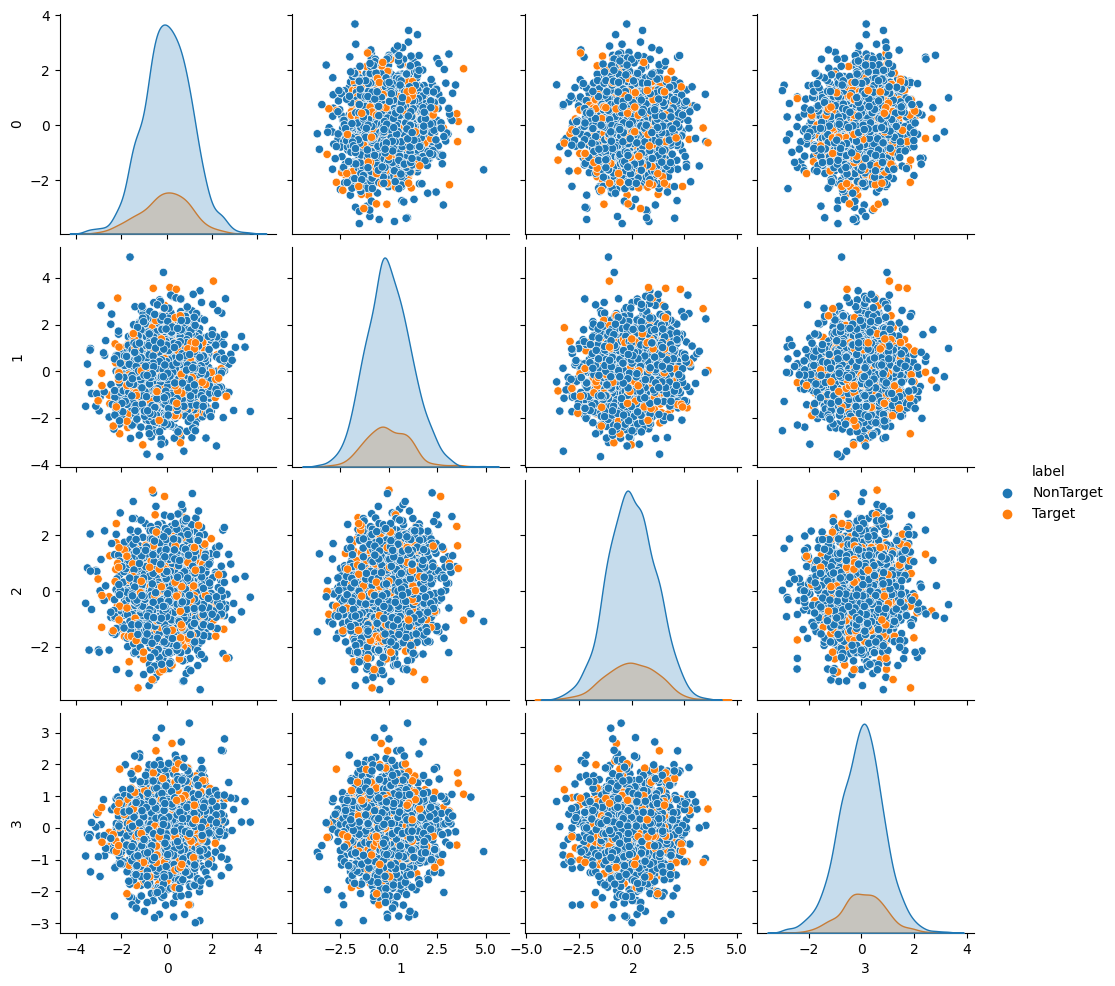

In [70]:
import seaborn as sns
import pandas as pd
Xt_train = hoda.transform(tl.tensor(X_train))
n_features = Xt_train.shape[-1]
df_train = pd.DataFrame(Xt_train[:,feature_order[:4]])
df_train['label'] = y_train
sns.pairplot(df_train, hue='label')
plt.show()

In [71]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.694850612244898

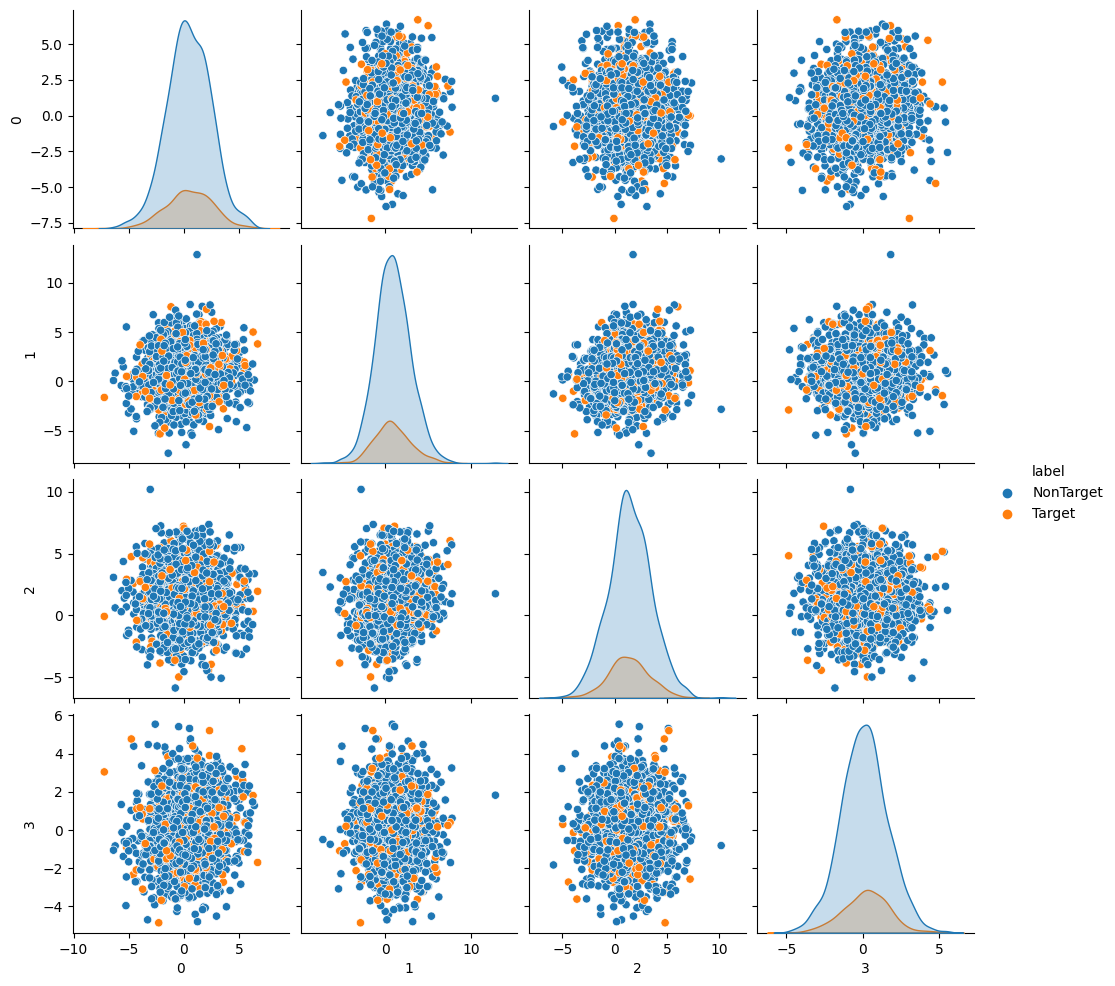

In [72]:
Xt_test = hoda.transform(tl.tensor(X_test))
df_test = pd.DataFrame(Xt_test[:,feature_order[:4]])
df_test['label'] = y_test
sns.pairplot(df_test, hue='label')
plt.show()

In [73]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.5175640816326531